<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>


#### Import the required libraries we need for the lab.


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [10]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 1.4 MB/s eta 0:00:0000:0100:01


#### Read the dataset in the csv file from the URL


In [2]:
# Load dataset
boston_df=pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv')

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [3]:
# Display first 5 rows
print(boston_df.head())

# Check for missing values
print("\nMissing values in dataset:")
print(boston_df.isnull().sum())

# Get dataset information
print("\nDataset Information:")
print(boston_df.info())

# Get summary statistics
print("\nSummary Statistics:")
print(boston_df.describe())


   Unnamed: 0     CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  \
0           0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0   
1           1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0   
2           2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0   
3           3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0   
4           4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0   

     TAX  PTRATIO  LSTAT  MEDV  
0  296.0     15.3   4.98  24.0  
1  242.0     17.8   9.14  21.6  
2  242.0     17.8   4.03  34.7  
3  222.0     18.7   2.94  33.4  
4  222.0     18.7   5.33  36.2  

Missing values in dataset:
Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
LSTAT         0
MEDV          0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeInd

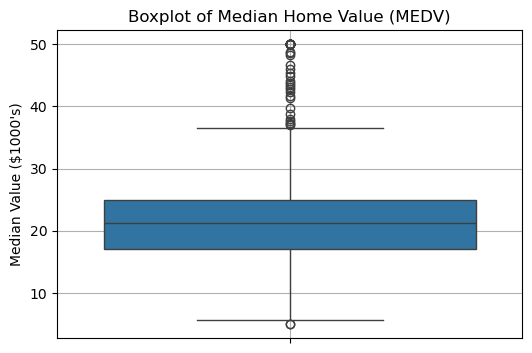

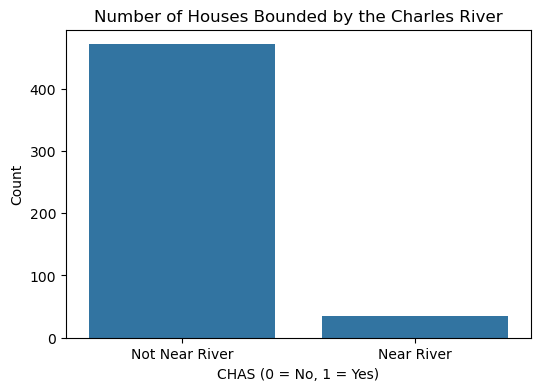

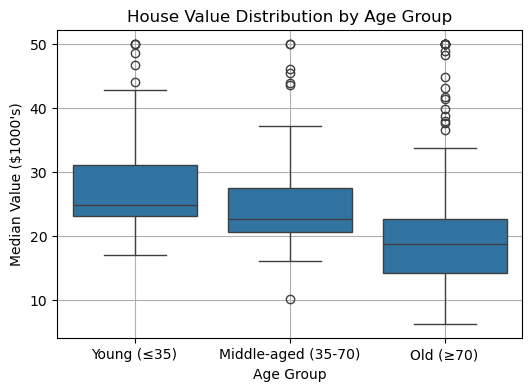

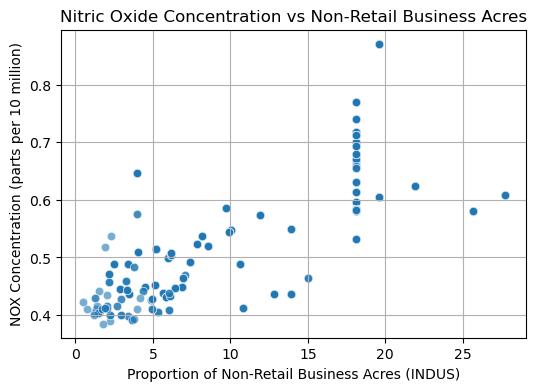

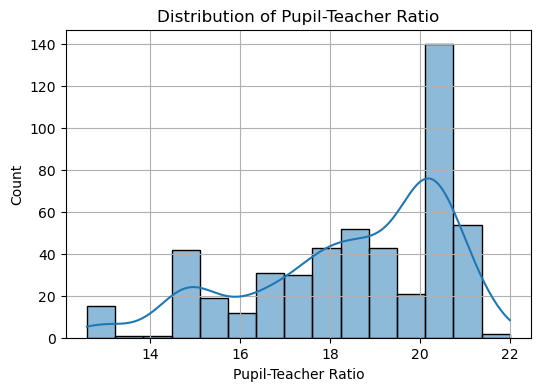

In [6]:
# Boxplot for Median Home Value (MEDV)
plt.figure(figsize=(6, 4))
sns.boxplot(y=boston_df["MEDV"])
plt.title("Boxplot of Median Home Value (MEDV)")
plt.ylabel("Median Value ($1000's)")
plt.grid(True)
plt.show()

# Bar plot for Charles River variable (CHAS)
plt.figure(figsize=(6, 4))
sns.countplot(x=boston_df["CHAS"])
plt.title("Number of Houses Bounded by the Charles River")
plt.xlabel("CHAS (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks([0, 1], ["Not Near River", "Near River"])
plt.show()

# Create age groups
bins = [0, 35, 70, 100]
labels = ["Young (≤35)", "Middle-aged (35-70)", "Old (≥70)"]
boston_df["AGE_Group"] = pd.cut(boston_df["AGE"], bins=bins, labels=labels, right=False)

# Boxplot for MEDV vs AGE groups
plt.figure(figsize=(6, 4))
sns.boxplot(x=boston_df["AGE_Group"], y=boston_df["MEDV"])
plt.title("House Value Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Value ($1000's)")
plt.grid(True)
plt.show()

# Scatter plot for NOX vs INDUS
plt.figure(figsize=(6, 4))
sns.scatterplot(x=boston_df["INDUS"], y=boston_df["NOX"], alpha=0.6)
plt.title("Nitric Oxide Concentration vs Non-Retail Business Acres")
plt.xlabel("Proportion of Non-Retail Business Acres (INDUS)")
plt.ylabel("NOX Concentration (parts per 10 million)")
plt.grid(True)
plt.show()

# Histogram for Pupil-Teacher Ratio (PTRATIO)
plt.figure(figsize=(6, 4))
sns.histplot(boston_df["PTRATIO"], bins=15, kde=True)
plt.title("Distribution of Pupil-Teacher Ratio")
plt.xlabel("Pupil-Teacher Ratio")
plt.ylabel("Count")
plt.grid(True)
plt.show()


T-test Results: t-statistic = 3.1133, p-value = 0.0036
Conclusion: We reject H₀. There is a significant difference in home values near the river.

ANOVA Results: F-statistic = 30.5668, p-value = 0.0000
Conclusion: We reject H₀. There is a significant difference in home values among age groups.

Pearson Correlation Results: r = 0.7637, p-value = 0.0000
Conclusion: We reject H₀. There is a significant correlation between NOX and INDUS.


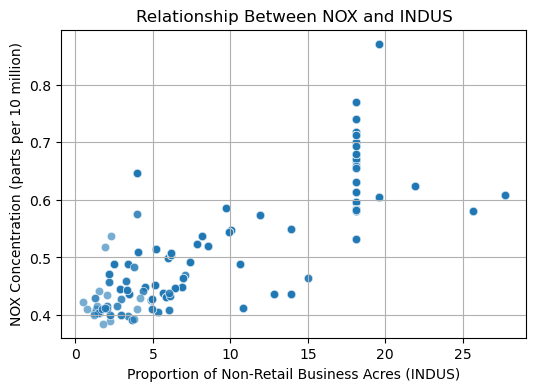


Regression Analysis: Impact of Distance to Employment Centers on Home Value
                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Sat, 22 Mar 2025   Prob (F-statistic):           1.21e-08
Time:                        06:08:54   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

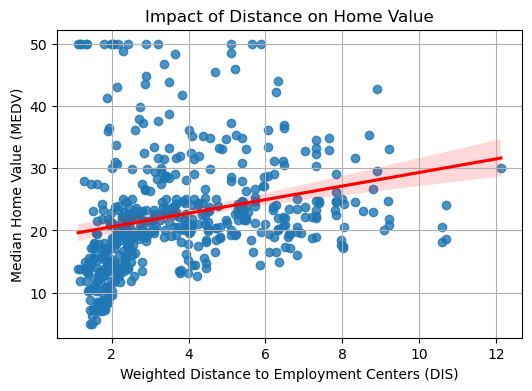

In [12]:
### 1️⃣ T-test: Impact of Charles River on Home Prices ###
# Split data into two groups: CHAS=1 (near river) and CHAS=0 (not near river)
medv_river = boston_df[boston_df["CHAS"] == 1]["MEDV"]
medv_no_river = boston_df[boston_df["CHAS"] == 0]["MEDV"]

# Perform T-test
t_stat, p_value = stats.ttest_ind(medv_river, medv_no_river, equal_var=False)
print(f"T-test Results: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: We reject H₀. There is a significant difference in home values near the river.")
else:
    print("Conclusion: We fail to reject H₀. No significant difference in home values near the river.")

### 2️⃣ ANOVA: Impact of Age Groups on Home Prices ###
# Define Age Groups
bins = [0, 35, 70, 100]
labels = ["Young (≤35)", "Middle-aged (35-70)", "Old (≥70)"]
boston_df["AGE_Group"] = pd.cut(boston_df["AGE"], bins=bins, labels=labels, right=False)

# Extract median values per group
medv_young = boston_df[boston_df["AGE_Group"] == "Young (≤35)"]["MEDV"]
medv_middle = boston_df[boston_df["AGE_Group"] == "Middle-aged (35-70)"]["MEDV"]
medv_old = boston_df[boston_df["AGE_Group"] == "Old (≥70)"]["MEDV"]

# Perform ANOVA test
f_stat, p_value_anova = stats.f_oneway(medv_young, medv_middle, medv_old)
print(f"\nANOVA Results: F-statistic = {f_stat:.4f}, p-value = {p_value_anova:.4f}")

if p_value_anova < 0.05:
    print("Conclusion: We reject H₀. There is a significant difference in home values among age groups.")
else:
    print("Conclusion: We fail to reject H₀. No significant difference in home values across age groups.")

### 3️⃣ Pearson Correlation: NOX vs. INDUS ###
corr_coeff, p_value_corr = stats.pearsonr(boston_df["NOX"], boston_df["INDUS"])
print(f"\nPearson Correlation Results: r = {corr_coeff:.4f}, p-value = {p_value_corr:.4f}")

if p_value_corr < 0.05:
    print("Conclusion: We reject H₀. There is a significant correlation between NOX and INDUS.")
else:
    print("Conclusion: We fail to reject H₀. No significant relationship between NOX and INDUS.")

# Scatter plot for NOX vs INDUS
plt.figure(figsize=(6, 4))
sns.scatterplot(x=boston_df["INDUS"], y=boston_df["NOX"], alpha=0.6)
plt.title("Relationship Between NOX and INDUS")
plt.xlabel("Proportion of Non-Retail Business Acres (INDUS)")
plt.ylabel("NOX Concentration (parts per 10 million)")
plt.grid(True)
plt.show()

### 4️⃣ Regression Analysis: Impact of Distance on Home Values ###
X = boston_df["DIS"]  # Independent Variable
y = boston_df["MEDV"]  # Dependent Variable

# Add constant to X
X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()

# Print summary
print("\nRegression Analysis: Impact of Distance to Employment Centers on Home Value")
print(model.summary())

# Plot Regression Line
plt.figure(figsize=(6, 4))
sns.regplot(x=boston_df["DIS"], y=boston_df["MEDV"], line_kws={"color": "red"})
plt.title("Impact of Distance on Home Value")
plt.xlabel("Weighted Distance to Employment Centers (DIS)")
plt.ylabel("Median Home Value (MEDV)")
plt.grid(True)
plt.show()
